In [1]:
import dnnlib.nlb_util_v2 as nlb_util
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def plot_frame(data, T, trial_idx, mean_image=None, n_img=6):

    idxs = np.linspace(0, T-1, n_img, dtype=int)

    # build array to plot: (T, H, W)
    X = np.asarray(data[trial_idx])
    if X.ndim == 4:  # (T, C, H, W)
        X = X[:, 0]
    if mean_image is not None:
        X = X + mean_image[None, ...]

    # one shared color range
    vmin, vmax = float(data.min()), float(data.max())
    # print([vmin, vmax])

    fig, axes = plt.subplots(1, len(idxs), figsize=(12, 2.6))
    last_im = None
    for ax, i in zip(axes, idxs):
        last_im = ax.imshow(X[i], cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f"t={i}")
        ax.axis("off")

    # single horizontal colorbar spanning all subplots
    fig.colorbar(last_im, ax=axes, orientation='horizontal', fraction=0.04, pad=0.15)
    plt.show()
def sigma_for_psnr(x, psnr_db=35, peak=None):
    if peak is None:
        lo, hi = np.percentile(x, 0.5), np.percentile(x, 99.5)  # robust dynamic range
        peak = hi - lo
    return peak * (10**(-psnr_db/20))

In [3]:
print(os.getcwd())

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt


In [4]:
dir_old = os.getcwd()
os.chdir('/home/ganchao')
folderpath = 'isilon/AllStaff/mice/mSM30/10-Oct-2017/Vc.mat'

# begin to read

In [5]:
import h5py
Vc_path=folderpath
data = h5py.File(Vc_path)
trials = data['trials'][()]
print(trials.shape[0])

395


In [6]:
_, _, train_video, _ = nlb_util.loader_musall_widefield(folderpath, recon_trial_num = trials.shape[0],
                                                       frame_resize_ratio = 64/640)

Read Vc.mat file...
reconstruct 395 trials...
processed widefield video shape: (trial, frame, x, y) (395, 205, 64, 54)
pad each frame to a square..
finish loading isilon/AllStaff/mice/mSM30/10-Oct-2017/Vc.mat


In [7]:
train_video_5d = train_video[:, :, np.newaxis, :, :]
x_min, x_max = np.min(train_video_5d), np.max(train_video_5d)  # from you
x = train_video_5d
x_norm = 2.0 * (x - x_min) / (x_max - x_min) - 1.0   # -> in [-1, 1]

In [8]:
x_norm.shape

(316, 205, 1, 64, 64)

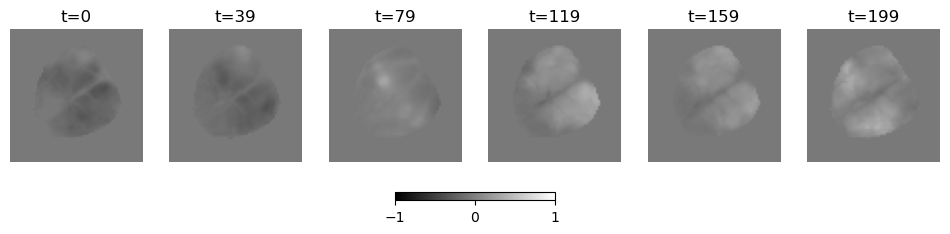

In [9]:
plot_frame(x_norm, 200, 0, None, 6)

In [10]:
os.chdir(dir_old)

In [11]:
1/30, np.max(x_norm), np.min(x_norm)

(0.03333333333333333, 1.0, -1.0)

Let's see how much noise I can use

0.01


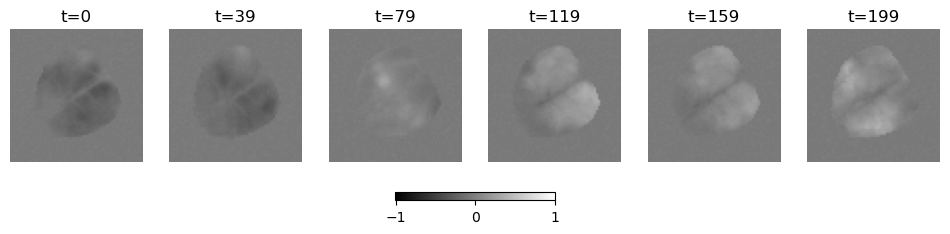

In [13]:
sigma = sigma_for_psnr(x_norm, psnr_db=20)
sigma = 0.01
print(sigma)
dset_samples_noise = x_norm.copy()
dset_samples_noise = x_norm + np.random.normal(scale=sigma, size=x_norm.shape)
plot_frame(dset_samples_noise, 200, 0, None, 6)

In [14]:
img5d = x_norm.astype(np.float32, copy=False)
np.savez("data/widefield/dataset_samples.npz", samples=img5d)